DBSCAN: density-based clustering that finds clusters of arbitrary shape and automatically flags outliers as noise, instead of forcing every point into a cluster like KMeans does.

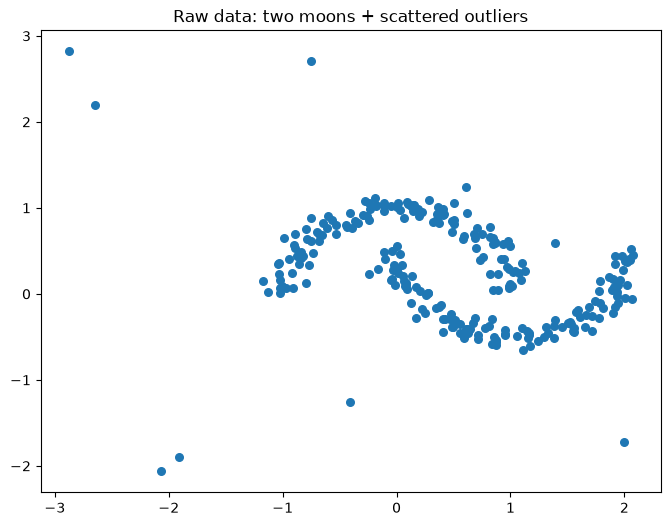

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X, y_true = make_moons(n_samples=250, noise=0.08, random_state=42)

# Add a few outlier points far from both moons
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-3, high=3, size=(10, 2))
X = np.vstack([X, outliers])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title('Raw data: two moons + scattered outliers')
plt.show()

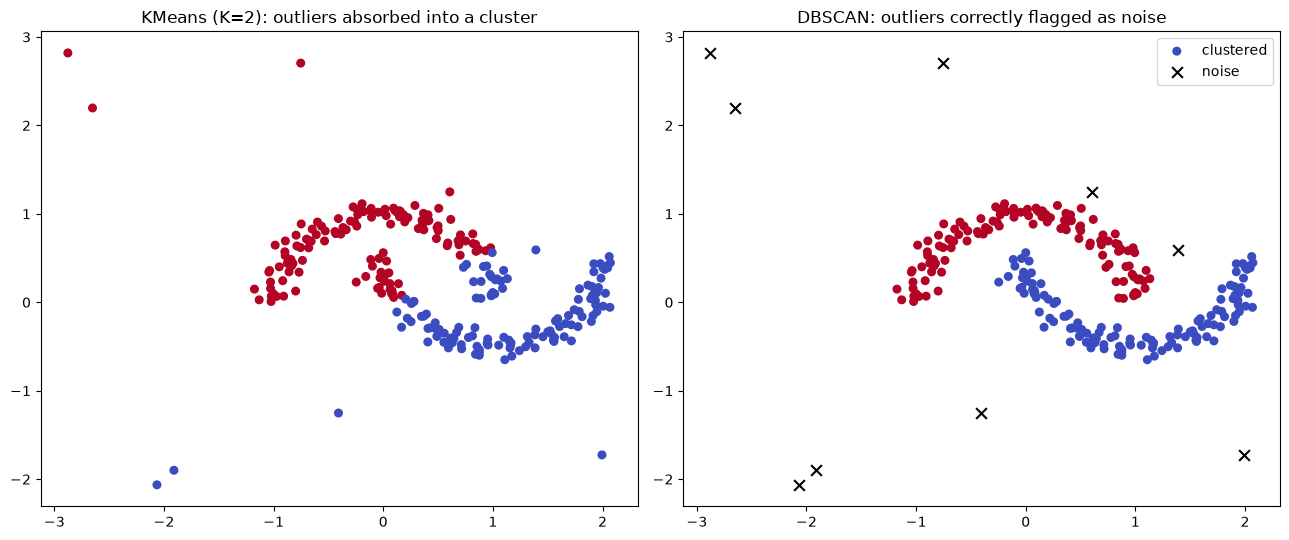

DBSCAN found 2 clusters and 9 noise points


In [2]:
# KMeans forces every point into a cluster -- including the outliers
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

# DBSCAN groups by density and labels sparse points as noise (-1)
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='coolwarm', s=30)
axes[0].set_title('KMeans (K=2): outliers absorbed into a cluster')

noise_mask = db_labels == -1
axes[1].scatter(X[~noise_mask, 0], X[~noise_mask, 1], c=db_labels[~noise_mask], cmap='coolwarm', s=30, label='clustered')
axes[1].scatter(X[noise_mask, 0], X[noise_mask, 1], c='black', marker='x', s=60, label='noise')
axes[1].set_title('DBSCAN: outliers correctly flagged as noise')
axes[1].legend()
plt.tight_layout()
plt.show()

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN found {n_clusters} clusters and {noise_mask.sum()} noise points")

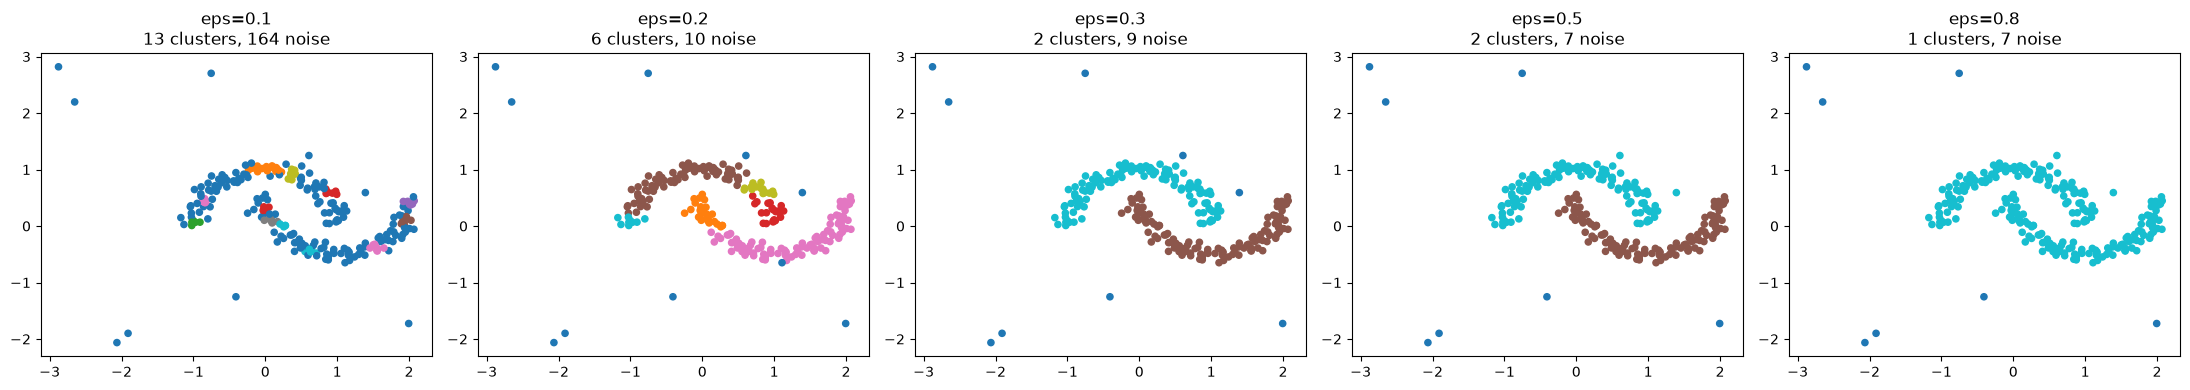

Too small eps -> everything is noise. Too large eps -> clusters merge into one blob.


In [3]:
# eps is the most important hyperparameter: max distance for two points to be "neighbors"
eps_values = [0.1, 0.2, 0.3, 0.5, 0.8]
fig, axes = plt.subplots(1, len(eps_values), figsize=(22, 4))

for ax, eps in zip(axes, eps_values):
    db_e = DBSCAN(eps=eps, min_samples=5)
    labels_e = db_e.fit_predict(X_scaled)
    n_clusters_e = len(set(labels_e)) - (1 if -1 in labels_e else 0)
    n_noise_e = np.sum(labels_e == -1)
    ax.scatter(X[:, 0], X[:, 1], c=labels_e, cmap='tab10', s=20)
    ax.set_title(f'eps={eps}\n{n_clusters_e} clusters, {n_noise_e} noise')

plt.tight_layout()
plt.show()
print("Too small eps -> everything is noise. Too large eps -> clusters merge into one blob.")

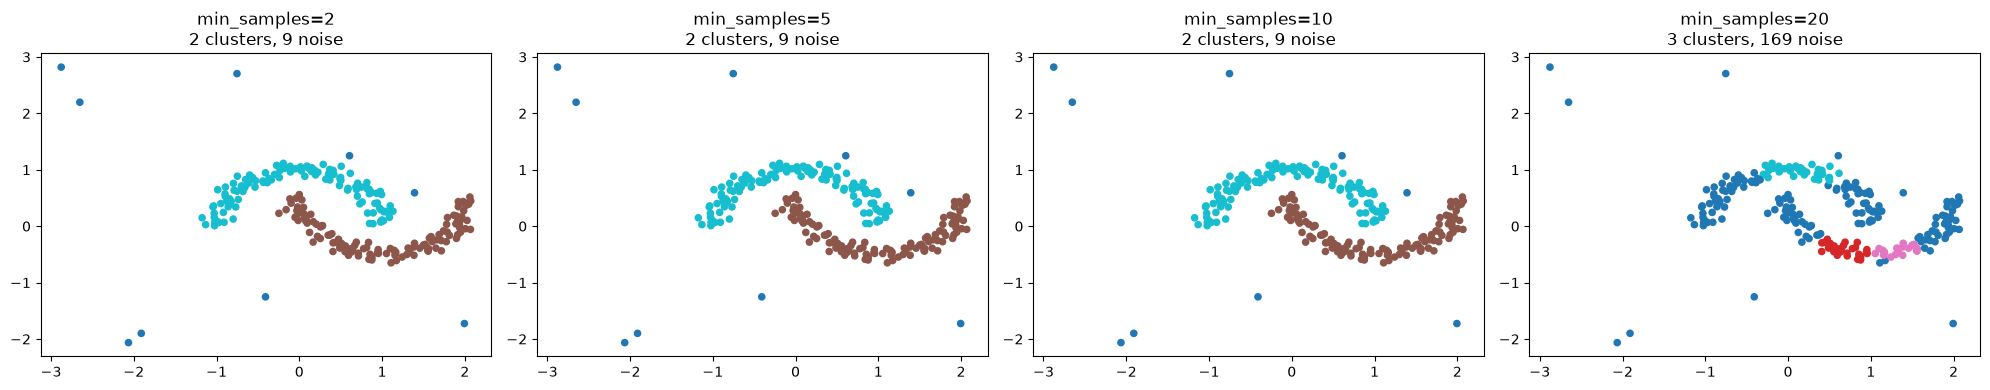

In [4]:
# min_samples controls how dense a neighborhood must be to seed a cluster
min_samples_values = [2, 5, 10, 20]
fig, axes = plt.subplots(1, len(min_samples_values), figsize=(20, 4))

for ax, ms in zip(axes, min_samples_values):
    db_m = DBSCAN(eps=0.3, min_samples=ms)
    labels_m = db_m.fit_predict(X_scaled)
    n_clusters_m = len(set(labels_m)) - (1 if -1 in labels_m else 0)
    n_noise_m = np.sum(labels_m == -1)
    ax.scatter(X[:, 0], X[:, 1], c=labels_m, cmap='tab10', s=20)
    ax.set_title(f'min_samples={ms}\n{n_clusters_m} clusters, {n_noise_m} noise')

plt.tight_layout()
plt.show()

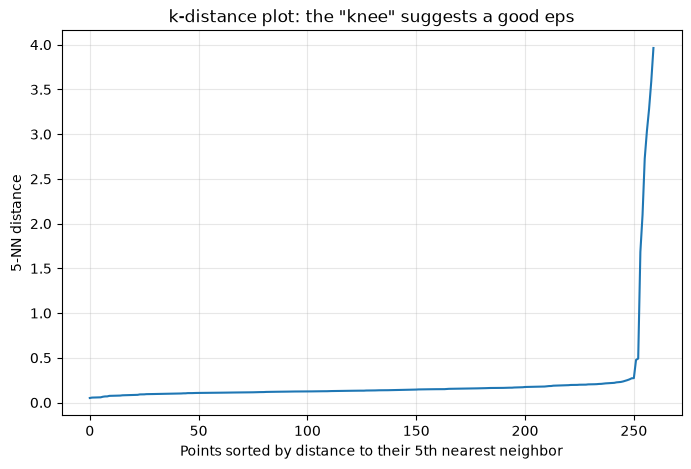

Pick eps at the point where the curve bends sharply upward (the 'knee').


In [5]:
# Using a k-distance plot to pick a reasonable eps (a common heuristic)
from sklearn.neighbors import NearestNeighbors

k = 5
neighbors = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel('Points sorted by distance to their 5th nearest neighbor')
plt.ylabel(f'{k}-NN distance')
plt.title('k-distance plot: the "knee" suggests a good eps')
plt.grid(True, alpha=0.3)
plt.show()
print("Pick eps at the point where the curve bends sharply upward (the 'knee').")